In [58]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
from sklearn.datasets import load_iris
irisRaw = load_iris()

In [55]:
iris = pd.DataFrame(data= np.c_[irisRaw['data'], irisRaw['target']],
                     columns= irisRaw['feature_names'] + ['target'])
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


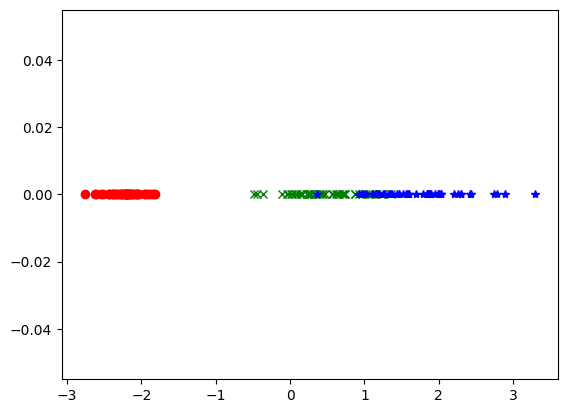

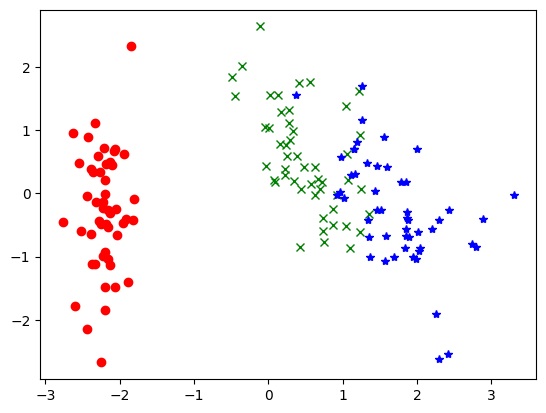

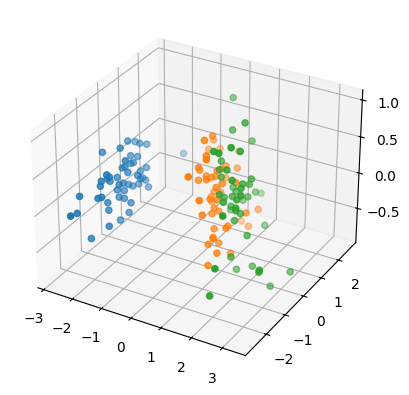

In [56]:
#ZAD 1

#1 Standaryzacja danych
for col in (iris.columns[:-1]):
    avg = iris[col].mean()
    std = iris[col].std()
    iris[col]=(iris[col]-avg)/std

irisnp = pd.DataFrame.to_numpy(iris)
irisnp = irisnp[:,:4]

#2 Obliczenie macierzy kowariancji
cov = np.cov(irisnp.T)

#3 Obliczenie wartości i wektorów własnych macierzy kowariancji
eigenvalues, eigenvectors = np.linalg.eig(cov)
#print(eigenvalues, eigenvectors)

#4 Przekształcenie danych
setosa = []
versicolor = []
virginica = []

Z=irisnp@eigenvectors[:,:3]

setosa.append(Z[iris['target']==0])
versicolor.append(Z[iris['target']==1])
virginica.append(Z[iris['target']==2])

#5 Wykresy
y=np.zeros(len(setosa[0]))

plt.plot(setosa[0][:,0], y, 'ro')
plt.plot(versicolor[0][:,0], y, 'gx')
plt.plot(virginica[0][:,0], y, 'b*')
plt.show()

plt.plot(setosa[0][:,0], setosa[0][:,1], 'ro')
plt.plot(versicolor[0][:,0], versicolor[0][:,1], 'gx')
plt.plot(virginica[0][:,0], virginica[0][:,1], 'b*')
plt.show()

ax = plt.axes(projection = "3d")
ax.scatter3D(setosa[0][:,0], setosa[0][:,1], setosa[0][:,2])
ax.scatter3D(versicolor[0][:,0], versicolor[0][:,1], versicolor[0][:,2])
ax.scatter3D(virginica[0][:,0], virginica[0][:,1], virginica[0][:,2])

In [41]:
#ZAD 2
#1
df = pd.read_csv('USArrests.csv', index_col=0)
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [43]:
 df.mean()

Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

In [44]:
df.var()

Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

In [45]:
#standarize the variables
from sklearn.preprocessing import scale

X = pd.DataFrame(scale(df), index=df.index, columns=df.columns)

print(X.mean())
print(X.var())

Murder     -7.105427e-17
Assault     1.387779e-16
UrbanPop   -4.396483e-16
Rape        8.593126e-16
dtype: float64
Murder      1.020408
Assault     1.020408
UrbanPop    1.020408
Rape        1.020408
dtype: float64


In [46]:
#compute the loading vectors
from sklearn.decomposition import PCA
pca_loadings = pd.DataFrame(PCA().fit(X).components_.T, index=df.columns, columns=['V1', 'V2', 'V3', 'V4'])
pca_loadings                            

,V1,V2,V3,V4
Murder,0.535899,0.418181,-0.341233,0.649228
Assault,0.583184,0.187986,-0.268148,-0.743407
UrbanPop,0.278191,-0.872806,-0.378016,0.133878
Rape,0.543432,-0.167319,0.817778,0.089024


In [47]:
#fit the PCA model and transform X to get the principal components
pca = PCA()
df_plot = pd.DataFrame(pca.fit_transform(X), columns=['PC1','PC2', 'PC3', 'PC4'], index=X.index)
df_plot.head()

,PC1,PC2,PC3,PC4
Alabama,0.985566,1.133392,-0.444269,0.156267
Alaska,1.950138,1.073213,2.040003,-0.438583
Arizona,1.763164,-0.745957,0.054781,-0.834653
Arkansas,-0.141420,1.119797,0.114574,-0.182811
California,2.523980,-1.542934,0.598557,-0.341996


C:\Users\emilk\AppData\Local\Temp\ipykernel_3920\3886557095.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.arrow(0,0,-pca_loadings.V1[0], -pca_loadings.V2[0])
C:\Users\emilk\AppData\Local\Temp\ipykernel_3920\3886557095.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.arrow(0,0,-pca_loadings.V1[1], -pca_loadings.V2[1])
C:\Users\emilk\AppData\Local\Temp\ipykernel_3920\3886557095.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se

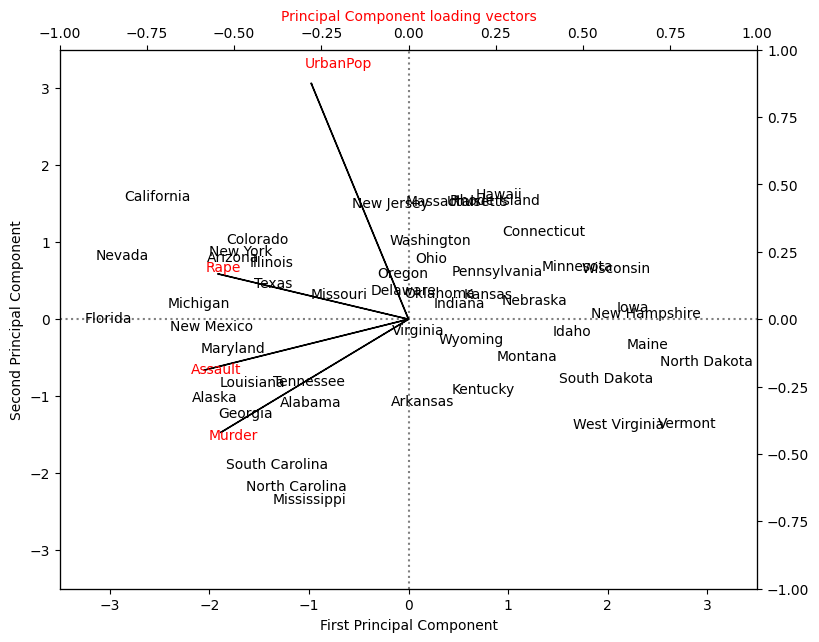

In [48]:
#construct a biplot of the first two principal components
fig, ax1 = plt.subplots(figsize=(9,7))

ax1.set_xlim(-3.5,3.5)
ax1.set_ylim(-3.5,3.5)

#Plot Principal Components 1 and 2
for i in df_plot.index:
    ax1.annotate(i, (-df_plot.PC1.loc[i], -df_plot.PC2.loc[i]), ha='center')

#Plot reference lines
ax1.hlines(0,-3.5,3.5, linestyles='dotted', colors='grey')
ax1.vlines(0,-3.5,3.5, linestyles='dotted', colors='grey')

ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

#Plot Principal Component loading vectors, using a second y-axis
ax2 = ax1.twinx().twiny()

ax2.set_ylim(-1,1)
ax2.set_xlim(-1,1)
ax2.set_xlabel('Principal Component loading vectors', color='red')

#Plot labels for vectors. Variable 'a' is a small offset parameter to separate arrow tip and text.
a = 1.07
for i in pca_loadings[['V1', 'V2']].index:
    ax2.annotate(i, (-pca_loadings.V1.loc[i]*a, -pca_loadings.V2.loc[i]*a), color='red')

#Plot vectors
ax2.arrow(0,0,-pca_loadings.V1[0], -pca_loadings.V2[0])
ax2.arrow(0,0,-pca_loadings.V1[1], -pca_loadings.V2[1])
ax2.arrow(0,0,-pca_loadings.V1[2], -pca_loadings.V2[2])
ax2.arrow(0,0,-pca_loadings.V1[3], -pca_loadings.V2[3])

In [49]:
#the variance explained by of each principal component
pca.explained_variance_

array([2.53085875, 1.00996444, 0.36383998, 0.17696948])

In [50]:
#the proportion of variance explained
pca.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

([<matplotlib.axis.XTick at 0x18ef6cea7e0>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3'), Text(4, 0, '4')])

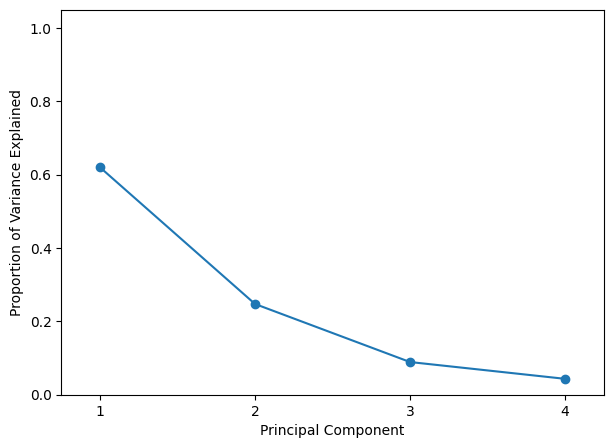

In [51]:
#We see that the first principal component explains 62.0% of the variance in the data, the next principal component
#explains 24.7% of the variance, and so forth. We can plot the PVE explained by each component as follows

plt.figure(figsize=(7,5))
plt.plot([1,2,3,4],pca.explained_variance_ratio_, '-o')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component')
plt.xlim(0.75,4.25)
plt.ylim(0,1.05)
plt.xticks([1,2,3,4])

([<matplotlib.axis.XTick at 0x18ef74ce4e0>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3'), Text(4, 0, '4')])

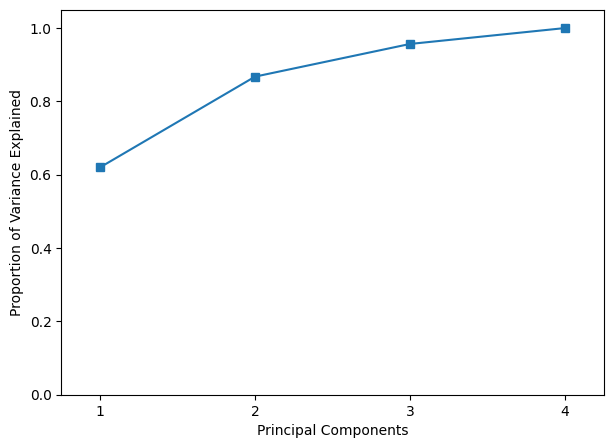

In [59]:
#We can also use the function cumsum(), which computes the cumulative sum of the elements of a numeric vector, to plot the cumulative PVE

plt.figure(figsize=(7,5))
plt.plot([1,2,3,4], np.cumsum(pca.explained_variance_ratio_), '-s')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Components')
plt.xlim(0.75,4.25)
plt.ylim(0,1.05)
plt.xticks([1,2,3,4]) 

In [60]:
###############################################################################

In [63]:
#2
#NCI60 consists of 6,830 gene expression measurements on 64 cancer cell lines
df2 = pd.read_csv('NCI60.csv').drop('Unnamed: 0', axis=1)
df2.columns = np.arange(df2.columns.size)
df2.info()

#read in the labels to check our work later
y = pd.read_csv('NCI60_y.csv', usecols=[1], skiprows=1, names=['type'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Columns: 6830 entries, 0 to 6829
dtypes: float64(6830)
memory usage: 3.3 MB


In [68]:
#Scale the data
X = pd.DataFrame(scale(df2))
print(X.shape)

#Fit the PCA model and transform X to get the principal components
pca2 = PCA()
df2_plot = pd.DataFrame(pca2.fit_transform(X))

(64, 6830)


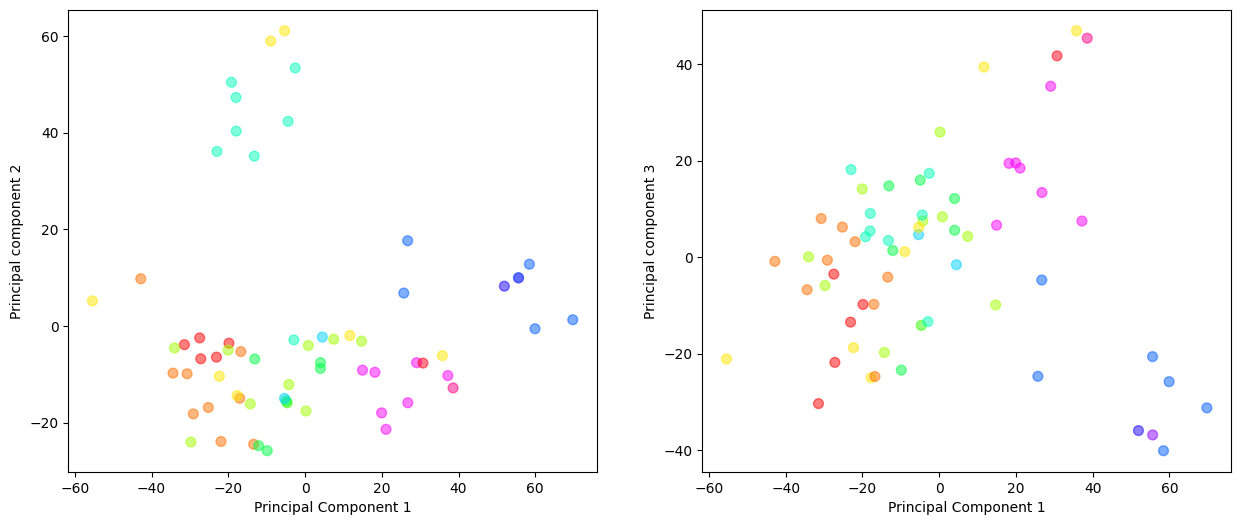

In [84]:
#We now plot the first few principal component score vectors, in order to visualize the data. The observations (cell lines) corresponding
#to a given cancer type will be plotted in the same color, so that we can seeto what extent the observations within a cancer type are
#similar to each other

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,6))

color_idx = pd.factorize(y.type)[0]
cmap = mpl.cm.hsv

#left plot
ax1.scatter(df2_plot.iloc[:,0], df2_plot.iloc[:,1], c=color_idx, cmap=cmap, alpha=0.5, s=50)
ax1.set_ylabel('Principal component 2')

#right plot
ax2.scatter(df2_plot.iloc[:,0], df2_plot.iloc[:,2], c=color_idx, cmap=cmap, alpha=0.5, s=50)
ax2.set_ylabel('Principal component 3')

#Custom legend for the classes (y) since we do not create scatter plots per class per class
handles = [0]
labels = pd.factorize(y.type.unique())
norm = mpl.colors.Normalize(vmin=0.0, vmax=14.0)

for i, v in zip(labels[0], labels[1]):
    handles.append(mpl.patches.Patch(color=cmap(norm(i)), label=v, alpha=0.5))
#ax2.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# xlabel for both plots
for ax in fig.axes:
    ax.set_xlabel('Principal Component 1')

In [83]:
#We can generate a summary of the proportion of variance explained (PVE) of the first few principal components

pd.DataFrame([df2_plot.iloc[:,:5].std(axis=0, ddof=0).to_numpy(),
              pca2.explained_variance_ratio_[:5],
              np.cumsum(pca2.explained_variance_ratio_[:5])],
             index=['Standard Deviation', 'Proportion of Variance', 'Cumulative Proportion'],
             columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

,PC1,PC2,PC3,PC4,PC5
Standard Deviation,27.853469,21.481355,19.820465,17.032556,15.971807
Proportion of Variance,0.113589,0.067562,0.057518,0.042476,0.037350
Cumulative Proportion,0.113589,0.181151,0.238670,0.281145,0.318495


Text(0, 0.5, 'Variances')

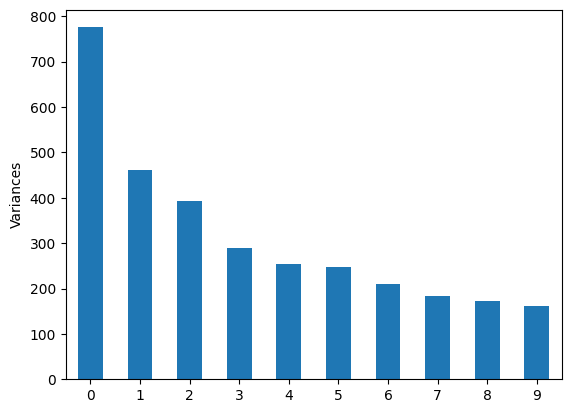

In [81]:
#we can also plot the variance explained by the first few principal components:
df2_plot.iloc[:,:10].var(axis=0, ddof=0).plot(kind='bar', rot=0)
plt.ylabel('Variances')

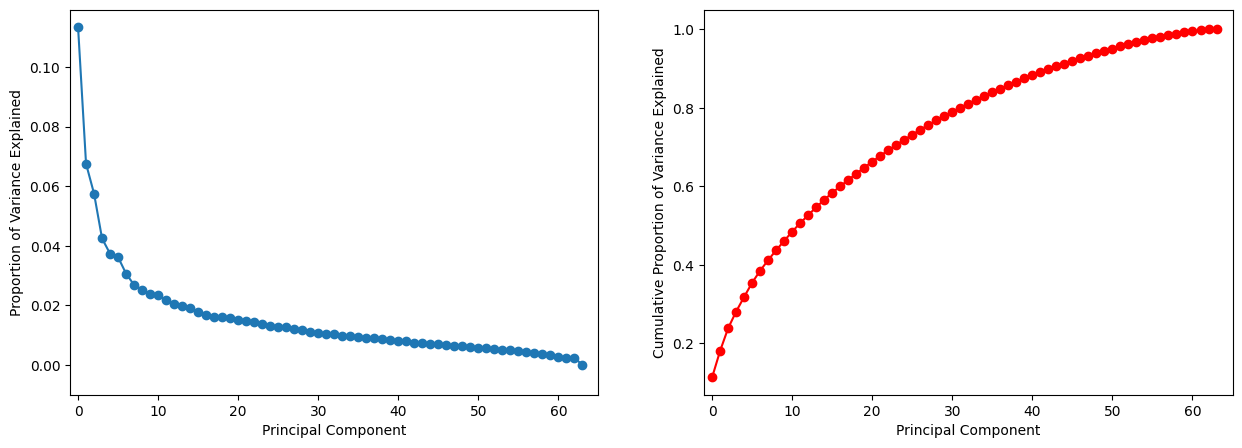

In [85]:
#plot the PVE of each principal component and the cumulative PVE of each principal component

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))

#left plot
ax1.plot(pca2.explained_variance_ratio_, '-o')
ax1.set_ylabel('Proportion of Variance Explained')
ax1.set_ylim(ymin=-0.01)

#right plot
ax2.plot(np.cumsum(pca2.explained_variance_ratio_), '-ro')
ax2.set_ylabel('Cumulative Proportion of Variance Explained')
ax2.set_ylim(ymax=1.05)

for ax in fig.axes:
    ax.set_xlabel('Principal Component')
    ax.set_xlim(-1,65)